## Groceries Dataset

### Association Rule Mining
Market Basket Analysis is one of the key techniques used by large retailers to uncover associations between items. It works by looking for combinations of items that occur together frequently in transactions. To put it another way, it allows retailers to identify relationships between the items that people buy.

Association Rules are widely used to analyze retail basket or transaction data and are intended to identify strong rules discovered in transaction data using measures of interestingness, based on the concept of strong rules.

### Details of the dataset
The dataset has 38765 rows of the purchase orders of people from the grocery stores. These orders can be analysed and association rules can be generated using Market Basket Analysis by algorithms like Apriori Algorithm.

### Apriori Algorithm
Apriori is an algorithm for frequent itemset mining and association rule learning over relational databases. It proceeds by identifying the frequent individual items in the database and extending them to larger and larger item sets as long as those item sets appear sufficiently often in the database. The frequent itemsets determined by Apriori can be used to determine association rules which highlight general trends in the database: this has applications in domains such as market basket analysis.

----------------------------------------

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

### Load & Preview Dataset

In [2]:
df = pd.read_csv("../datasets/Groceries_dataset.csv")
df.shape

(38765, 3)

In [3]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
df.tail()

,Member_number,Date,itemDescription
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [5]:
df.sample(10)

,Member_number,Date,itemDescription
7083,1430,27-10-2015,beef
26949,1051,17-09-2014,coffee
23519,2365,21-06-2015,other vegetables
27769,3188,16-10-2014,chocolate marshmallow
4048,4324,05-01-2015,sausage
7643,2265,25-09-2015,waffles
34276,2104,02-07-2014,bottled water
19083,2419,22-08-2015,whole milk
23343,1306,23-06-2015,yogurt
28260,3435,22-01-2014,bottled water


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [7]:
df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(759)

In [9]:
df[df.duplicated(keep=False)].sort_values(by=["Member_number", "Date"], ascending=True)

,Member_number,Date,itemDescription
33098,1003,27-02-2014,rolls/buns
37649,1003,27-02-2014,rolls/buns
15099,1005,09-01-2014,rolls/buns
31248,1005,09-01-2014,rolls/buns
7532,1006,14-06-2015,frankfurter
...,...,...,...
24043,4981,10-01-2015,margarine
8109,4988,29-10-2015,rolls/buns
24258,4988,29-10-2015,rolls/buns
33585,4992,24-02-2014,margarine


In [10]:
df.drop_duplicates(inplace=True)

### Prepare data for Apriori Algorithm

In [11]:
transactions = df.groupby("Member_number")["itemDescription"].apply(list).values.tolist()

encoder = TransactionEncoder()
transactions_trf = encoder.fit_transform(transactions)

df = pd.DataFrame(transactions_trf, columns=encoder.columns_)
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Generate frequent itemsets

In [12]:
frequent_itemsets  = apriori(df, min_support=0.03, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.078502,(UHT-milk)
1,0.031042,(baking powder)
2,0.119548,(beef)
3,0.079785,(berries)
4,0.062083,(beverages)
...,...,...
410,0.039764,"(tropical fruit, soda, whole milk)"
411,0.054387,"(yogurt, soda, whole milk)"
412,0.042329,"(tropical fruit, whole milk, yogurt)"
413,0.031811,"(rolls/buns, whole milk, other vegetables, soda)"


### Generate Association Rules

In [13]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
3,(beef),(other vegetables),0.119548,0.376603,0.050795,0.424893,1.128223,1.0,0.005773,1.083966,0.129082,0.114055,0.077462,0.279885
4,(beef),(rolls/buns),0.119548,0.349666,0.040534,0.339056,0.969655,1.0,-0.001268,0.983946,-0.034324,0.094554,-0.016316,0.227488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366,"(yogurt, rolls/buns, whole milk)",(other vegetables),0.065931,0.376603,0.034377,0.521401,1.384482,1.0,0.009547,1.302544,0.297310,0.084224,0.232272,0.306341
367,"(yogurt, rolls/buns, other vegetables)",(whole milk),0.052335,0.458184,0.034377,0.656863,1.433623,1.0,0.010398,1.579008,0.319170,0.072198,0.366691,0.365945
368,"(yogurt, whole milk, other vegetables)",(rolls/buns),0.071832,0.349666,0.034377,0.478571,1.368651,1.0,0.009259,1.247215,0.290199,0.088801,0.198214,0.288442
369,"(rolls/buns, whole milk, other vegetables)",(yogurt),0.082093,0.282966,0.034377,0.418750,1.479862,1.0,0.011147,1.233608,0.353262,0.103957,0.189369,0.270118


### Visualize top frequent items

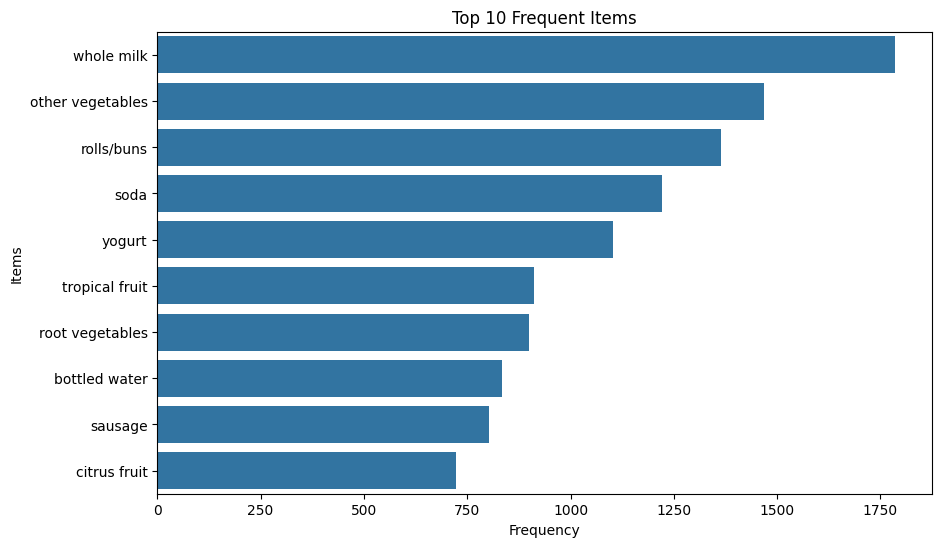

In [14]:
item_frequencies = df.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x = item_frequencies.head(10).values, y = item_frequencies.head(10).index)

plt.title("Top 10 Frequent Items")
plt.xlabel("Frequency")
plt.ylabel("Items")

plt.show()

### Scatterplot of Rules(support vs confidence)

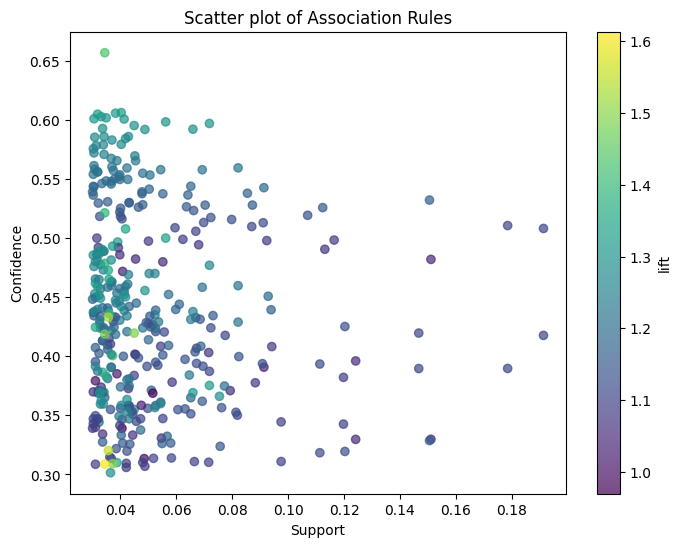

In [15]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="lift")

plt.title("Scatter plot of Association Rules")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()